# Проект. Исследование рынка стартапов

- Автор: Мельников Даниил
- Дата: 21.02.2026 г.

# Содержание
[1. Введение](#введение)  
[2. Знакомство с данными: загрузка и предобработка](#знакомство-с-данными:-загрузка-и-предобработка)  
&nbsp;&nbsp;[2.1. Вывод общей информации](#вывод-общей-информации)  
&nbsp;&nbsp;[2.2. Предобработка данных](#предобработка-данных)  
[3. Инжиниринг признаков](#инжиниринг-признаков)  
&nbsp;&nbsp;[3.1. Группы по срокам финансирования](#группы-по-срокам-финансирования)  
&nbsp;&nbsp;[3.2. Выделение средних и нишевых сегментов рынка](#выделение-средних-и-нишевых-сегментов-рынка)  
[4. Работа с выбросами и анализ](#работа-с-выбросами-и-анализ)  
&nbsp;&nbsp;[4.1. Анализируем и помечаем выбросы в каждом из сегментов](#анализируем-и-помечаем-выбросы-в-каждом-из-сегментов)  
&nbsp;&nbsp;[4.2. Определяем границы рассматриваемого периода, отбрасываем аномалии](#определяем-границы-рассматриваемого-периода,-отбрасываем-аномалии)  
&nbsp;&nbsp;[4.3. Анализ типов финансирования по объёму и популярности](#анализ-типов-финансирования-по-объёму-и-популярности) 
[5. Анализ динамики](#анализ-динамики)  
&nbsp;&nbsp;[5.1. Динамика предоставления финансирования по годам](#динамика-предоставления-финансирования-по-годам)  
&nbsp;&nbsp;[5.2. Динамика размера общего финансирования по массовым сегментам рынка для растущих в 2014 году сегментов](#динамика-размера-общего-финансирования-по-массовым-сегментам-рынка-для-растущих-в-2014-году-сегментов)  
&nbsp;&nbsp;[5.3. Годовая динамика доли возвращённых средств по типам финансирования](#годовая-динамика-доли-возвращённых-средств-по-типам-финансирования)  
[6. Итоговый вывод и рекомендации](#итоговый-вывод-и-рекомендации)

## Введение

**Контекст:** Финансовая компания, работающая с венчурными инвестициями, хочет понять закономерности финансирования стартапов и оценить перспективы выхода на рынок с покупкой и развитием компаний. Исследование проводится на исторических данных.

**Цель проекта** - исследовать динамику и структуру финансирования стартапов.

**Задачи:**
1. Провести предобработку данных.
2. Выделить группы компаний по срокам финансирования и сравнить их по количеству и объёму инвестиций.
3. Классифицировать сегменты рынка.
4. Определить типичные и аномальные значения объёмов финансирования, исключить выбросы и ограничить период исследования.
5. Сравнить популярность и объёмы разных типов финансирования.
6. Проанализировать динамику раундов и объёмов инвестиций по годам, а также изменения в массовых сегментах рынка.
7. Рассчитать долю возврата средств для разных типов финансирования и оценить её устойчивость.
8. Подвести итоговые выводы и дать рекомендации, учитывая исторический контекст данных исследования.

## Знакомство с данными: загрузка и предобработка

Датасет получен из базы данных стартапов.

Название основного датасета — `cb_investments.zip`. Внутри архива один файл — `cb_investments.csv`.

Описание данных:
* `name` — название компании.
* `homepage_url` — ссылка на сайт компании.
* `category_list` — категории, в которых работает компания. Указываются через `|`.
* `market` — основной рынок или отрасль компании.
* `funding_total_usd` — общий объём привлечённых инвестиций в долларах США.
* `status` — текущий статус компании, например `operating`, `closed` и так далее.
* `country_code` — код страны, например USA.
* `state_code` — код штата или региона, например, CA.
* `region` — регион, например, SF Bay Area.
* `city` — город, в котором расположена компания.
* `funding_rounds` — общее число раундов финансирования.
* `participants` — число участников в раундах финансирования.
* `founded_at` — дата основания компании.
* `founded_month` — месяц основания в формате `YYYY-MM`.
* `founded_quarter` — квартал основания в формате `YYYY-QN`.
* `founded_year` — год основания.
* `first_funding_at` — дата первого финансирования.
* `mid_funding_at` — дата среднего по времени раунда финансирования.
* `last_funding_at` — дата последнего финансирования.
* `seed` — сумма инвестиций на посевной стадии.
* `venture` — сумма венчурных инвестиций.
* `equity_crowdfunding` — сумма, привлечённая через долевой краудфандинг.
* `undisclosed` — сумма финансирования нераскрытого типа.
* `convertible_note` — сумма инвестиций через конвертируемые займы.
* `debt_financing` — сумма долгового финансирования.
* `angel` — сумма инвестиций от бизнес-ангелов.
* `grant` — сумма полученных грантов.
* `private_equity` — сумма инвестиций в виде прямых (частных) вложений.
* `post_ipo_equity` — сумма финансирования после IPO.
* `post_ipo_debt` — сумма долгового финансирования после IPO.
* `secondary_market` — сумма сделок на вторичном рынке.
* `product_crowdfunding` — сумма, привлечённая через продуктовый краудфандинг.
* `round_A` — `round_H` — сумма инвестиций в соответствующем раунде.

Название дополнительного датасета — `cb_returns.csv`. Он содержит суммы возвратов по типам финансирования в миллионах долларов по годам.

Описание данных:
* `year` — год возврата средств.
* `seed` — сумма возвратов от посевных инвестиций.
* `venture` — сумма возвратов от венчурных инвестиций.
* `equity_crowdfunding` — сумма, возвращённая по долевому краудфандингу.
* `undisclosed` — сумма возвратов нераскрытого типа.
* `convertible_note` — сумма возвратов через конвертируемые займы.
* `debt_financing` — сумма возвратов от долгового финансирования.
* `angel` — сумма возвратов бизнес-ангелам.
* `grant` — сумма возвратов по грантам.
* `private_equity` — сумма возвратов прямых (частных) вложений.
* `post_ipo_equity` — сумма возвратов от IPO.
* `post_ipo_debt` — сумма возвратов от долгового IPO.
* `secondary_market` — сумма возвратов от сделок на вторичном рынке.
* `product_crowdfunding` — сумма возвратов по продуктовому краудфандингу.

### Вывод общей информации

In [1]:
# Выгружаем pandas для работы с данными
import pandas as pd

In [2]:
# Выгружаем matplotlib для создания визуализаций
import matplotlib.pyplot as plt

In [3]:
# Выгружаем датасет сb_investements
try:
    cb_investments = pd.read_csv(r"C:\Users\Mi\Downloads\cb_investments\cb_investments.csv", sep=';', low_memory=False)
except FileNotFoundError:
    df = pd.read_csv("/datasets/cb_investments.zip", sep=';', low_memory=False)

In [4]:
try:
    cb_returns = pd.read_csv(r"C:\Users\Mi\Downloads\cb_returns.csv", sep=',', low_memory=False)
except FileNotFoundError:
    df = pd.read_csv("/datasets/cb_investments.zip", sep=';', low_memory=False)

In [5]:
cb_investments.info()
cb_investments.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 54294 entries, 0 to 54293
Data columns (total 40 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   name                  49437 non-null  object 
 1   homepage_url          45989 non-null  object 
 2   category_list         45477 non-null  object 
 3    market               45477 non-null  object 
 4    funding_total_usd    49438 non-null  object 
 5   status                48124 non-null  object 
 6   country_code          44165 non-null  object 
 7   state_code            30161 non-null  object 
 8   region                44165 non-null  object 
 9   city                  43322 non-null  object 
 10  funding_rounds        49438 non-null  float64
 11  participants          30473 non-null  float64
 12  founded_at            38554 non-null  object 
 13  founded_month         38482 non-null  object 
 14  founded_quarter       38482 non-null  object 
 15  founded_year       

,name,homepage_url,category_list,market,funding_total_usd,status,country_code,state_code,region,city,...,secondary_market,product_crowdfunding,round_A,round_B,round_C,round_D,round_E,round_F,round_G,round_H
0,Harvard University,http://harvard.edu,|Education|,Education,"9,00,00,000",operating,USA,MA,Boston,Cambridge,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,University of New Brunswick,http://www.unb.ca,NaN,NaN,"20,00,000",operating,NaN,NaN,NaN,NaN,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,DuPont,http://www.dupont.com,|Business Services|Agriculture|Automotive|Inve...,Business Services,"90,00,000",operating,USA,DE,"Wilmington, Delaware",Wilmington,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,University of Michigan,http://www.umich.edu/,|Education|,Education,"77,00,000",operating,USA,MI,Detroit,Ann Arbor,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,Case Western Reserve University,http://www.case.edu,|Education|,Education,"5,40,000",operating,USA,OH,Cleveland,Cleveland,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [6]:
cb_returns.info()
cb_returns

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15 entries, 0 to 14
Data columns (total 14 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   year                  15 non-null     int64  
 1   seed                  15 non-null     float64
 2   venture               15 non-null     float64
 3   equity_crowdfunding   15 non-null     float64
 4   undisclosed           15 non-null     float64
 5   convertible_note      15 non-null     float64
 6   debt_financing        15 non-null     float64
 7   angel                 15 non-null     float64
 8   grant                 15 non-null     float64
 9   private_equity        15 non-null     float64
 10  post_ipo_equity       15 non-null     float64
 11  post_ipo_debt         15 non-null     float64
 12  secondary_market      15 non-null     float64
 13  product_crowdfunding  15 non-null     float64
dtypes: float64(13), int64(1)
memory usage: 1.8 KB


,year,seed,venture,equity_crowdfunding,undisclosed,convertible_note,debt_financing,angel,grant,private_equity,post_ipo_equity,post_ipo_debt,secondary_market,product_crowdfunding
0,2000,16.70,55.40,0.00,78.21,0.00,8.66,6.43,0.0,0.00,0.94,0.00,0.20,0.00
1,2001,2.88,23.49,0.00,21.50,0.01,4.49,1.18,0.0,0.00,0.46,0.00,0.46,0.00
2,2002,6.59,209.42,0.00,25.77,0.02,3.42,3.41,0.0,1.51,0.34,0.00,0.06,0.00
3,2003,7.74,233.86,0.00,9.40,0.01,1.09,3.41,0.0,1.62,2.11,0.00,0.08,0.00
4,2004,9.93,555.90,0.00,33.19,0.01,13.55,9.18,0.0,2.19,3.38,0.00,0.55,0.00
5,2005,26.60,2628.92,0.00,9.51,0.02,35.09,31.06,0.0,2.40,3.51,0.00,0.05,0.00
6,2006,61.81,3100.18,0.19,46.74,1.78,113.21,47.75,0.0,16.67,20.58,0.00,0.12,0.00
7,2007,70.41,3585.37,0.01,55.37,3.22,125.68,164.51,0.0,88.81,24.36,0.00,0.57,0.00
8,2008,89.72,2717.02,0.03,41.02,1.71,397.54,102.83,0.0,130.38,84.28,0.00,0.47,0.00
9,2009,160.21,2501.29,0.18,37.50,2.25,394.10,97.21,0.0,203.70,76.76,0.00,0.12,0.02


Датафрейм `cb_investments` содержит 54294 строк и 40 столбцов. В каждом столбце по тем или иным причинам присутствуют пропуски. Данные, имеющиеся в столбцах, соответствуют описанию, но столбцы `funding_total_usd`, `founded_month`, `founded_quarter`, `founded_year` необходимо привести к целочисленному типу, а столбцы `founded_at`, `first_funding_at`, `mid_funding_at`, `last_funding_at` к типу datetime для корректной работы с данными. Также необходимо избавиться от лишних пробелов в столбцах `market` и `funding_total_usd`.

Датафрейм `cb_returns` содержит 15 строк, 14 столбцов. Данные соответсвуют описанию и содержатся в корректных типах данных. Пропуски отсутствуют. Данные не требуют дальнейшей предобработки.

### Предобработка данных

In [7]:
# Избавляемся от лишних пробелов в столбцах
cb_investments.columns = cb_investments.columns.str.strip()

In [8]:
# Приводим к snake_case названия компаний
cb_investments['name'] = cb_investments['name'].str.lower()

In [9]:
# Убираем разряды в столбце funding_total_usd
cb_investments['funding_total_usd'] = cb_investments['funding_total_usd'].str.replace(',','')
cb_investments['funding_total_usd']

0         90000000 
1          2000000 
2          9000000 
3          7700000 
4           540000 
            ...    
54289           NaN
54290           NaN
54291           NaN
54292           NaN
54293           NaN
Name: funding_total_usd, Length: 54294, dtype: object

In [10]:
# Приводим столбец к целочисленному формату
cb_investments['funding_total_usd'] = pd.to_numeric(cb_investments['funding_total_usd'], errors='coerce')
cb_investments['funding_total_usd'].astype('Int64')

0        90000000
1         2000000
2         9000000
3         7700000
4          540000
           ...   
54289        <NA>
54290        <NA>
54291        <NA>
54292        <NA>
54293        <NA>
Name: funding_total_usd, Length: 54294, dtype: Int64

In [11]:
# Приводим столбцы к целочисленному формату
cb_investments['founded_month'] = pd.to_numeric(cb_investments['founded_month'], errors='coerce')
cb_investments['founded_month'].astype('Int64')

cb_investments['founded_quarter'] = pd.to_numeric(cb_investments['founded_quarter'], errors='coerce')
cb_investments['founded_quarter'].astype('Int64')

cb_investments['founded_year'].astype('Int64')

0        1636
1        1785
2        1802
3        1817
4        1826
         ... 
54289    <NA>
54290    <NA>
54291    <NA>
54292    <NA>
54293    <NA>
Name: founded_year, Length: 54294, dtype: Int64

In [12]:
# Приводим столбцы к формату datetime
cb_investments['founded_at'] = pd.to_datetime(cb_investments['founded_at'], format='%Y-%m-%d', errors='coerce')
cb_investments['first_funding_at'] = pd.to_datetime(cb_investments['first_funding_at'], format='%Y-%m-%d', errors='coerce')
cb_investments['mid_funding_at'] = pd.to_datetime(cb_investments['mid_funding_at'], format='%Y-%m-%d', errors='coerce')
cb_investments['last_funding_at'] = pd.to_datetime(cb_investments['last_funding_at'], format='%Y-%m-%d', errors='coerce')

В датасете `cb_returns` сделайте столбец `year` индексом всего датасета, если не делали это при загрузке.

In [13]:
# Форматируем столбец year в индекс по датасету
cb_returns.set_index('year')

,seed,venture,equity_crowdfunding,undisclosed,convertible_note,debt_financing,angel,grant,private_equity,post_ipo_equity,post_ipo_debt,secondary_market,product_crowdfunding
year,,,,,,,,,,,,,
2000,16.70,55.40,0.00,78.21,0.00,8.66,6.43,0.0,0.00,0.94,0.00,0.20,0.00
2001,2.88,23.49,0.00,21.50,0.01,4.49,1.18,0.0,0.00,0.46,0.00,0.46,0.00
2002,6.59,209.42,0.00,25.77,0.02,3.42,3.41,0.0,1.51,0.34,0.00,0.06,0.00
2003,7.74,233.86,0.00,9.40,0.01,1.09,3.41,0.0,1.62,2.11,0.00,0.08,0.00
2004,9.93,555.90,0.00,33.19,0.01,13.55,9.18,0.0,2.19,3.38,0.00,0.55,0.00
2005,26.60,2628.92,0.00,9.51,0.02,35.09,31.06,0.0,2.40,3.51,0.00,0.05,0.00
2006,61.81,3100.18,0.19,46.74,1.78,113.21,47.75,0.0,16.67,20.58,0.00,0.12,0.00
2007,70.41,3585.37,0.01,55.37,3.22,125.68,164.51,0.0,88.81,24.36,0.00,0.57,0.00
2008,89.72,2717.02,0.03,41.02,1.71,397.54,102.83,0.0,130.38,84.28,0.00,0.47,0.00


In [14]:
# Находим долю пропусков в текстовых столбцах
text_columns = cb_investments.select_dtypes(include='object').columns

for col in text_columns:
    isna_ratio = round(cb_investments[col].isna().mean(), 2) * 100
    print(f'Доля пропусков в столбце {col}: {isna_ratio}%')

Доля пропусков в столбце name: 9.0%
Доля пропусков в столбце homepage_url: 15.0%
Доля пропусков в столбце category_list: 16.0%
Доля пропусков в столбце market: 16.0%
Доля пропусков в столбце status: 11.0%
Доля пропусков в столбце country_code: 19.0%
Доля пропусков в столбце state_code: 44.0%
Доля пропусков в столбце region: 19.0%
Доля пропусков в столбце city: 20.0%


In [15]:
# Заполняем пропуски в столбцах
selected_columns = ['name', 'market']

for col in selected_columns:
   cb_investments[col] = cb_investments[col].fillna('unknown')

In [16]:
# Удаляем явные дубликаты в funding_total_usd
clean_cb_investments = cb_investments.drop_duplicates(subset='funding_total_usd', keep='first')
clean_cb_investments

,name,homepage_url,category_list,market,funding_total_usd,status,country_code,state_code,region,city,...,secondary_market,product_crowdfunding,round_A,round_B,round_C,round_D,round_E,round_F,round_G,round_H
0,harvard university,http://harvard.edu,|Education|,Education,90000000.0,operating,USA,MA,Boston,Cambridge,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,university of new brunswick,http://www.unb.ca,NaN,unknown,2000000.0,operating,NaN,NaN,NaN,NaN,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,dupont,http://www.dupont.com,|Business Services|Agriculture|Automotive|Inve...,Business Services,9000000.0,operating,USA,DE,"Wilmington, Delaware",Wilmington,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,university of michigan,http://www.umich.edu/,|Education|,Education,7700000.0,operating,USA,MI,Detroit,Ann Arbor,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,case western reserve university,http://www.case.edu,|Education|,Education,540000.0,operating,USA,OH,Cleveland,Cleveland,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
49382,self care catalysts,http://www.selfcarecatalysts.com/,NaN,unknown,1770044.0,operating,NaN,NaN,NaN,NaN,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
49387,ottomatika,NaN,NaN,unknown,2256477.0,operating,USA,PA,Pittsburgh,Monroeville,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
49390,bella vita global s.l,https://www.facebook.com/BellaVitaGlobal,NaN,unknown,58971.0,operating,NaN,NaN,NaN,NaN,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
49391,bitreserve,http://bitreserve.org,NaN,unknown,7216365.0,operating,USA,CA,SF Bay Area,San Francisco,...,0.0,7216365.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [17]:
# Проверяем наличие пропусков
clean_cb_investments['funding_total_usd'].isna().sum()

np.int64(1)

In [18]:
# Удаляем строку с пропуском
clean_cb_investments = clean_cb_investments.dropna(subset='funding_total_usd')

In [19]:
# Находим срединную дату и заполняем ею пропуски
mid_date = clean_cb_investments['first_funding_at'] + (clean_cb_investments['last_funding_at'] - clean_cb_investments['first_funding_at']) / 2
clean_cb_investments['mid_funding_at'] = clean_cb_investments['mid_funding_at'].fillna(mid_date)

C:\Users\Mi\AppData\Local\Temp\ipykernel_12016\2052692252.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  clean_cb_investments['mid_funding_at'] = clean_cb_investments['mid_funding_at'].fillna(mid_date)


In [20]:
# Анализируем оставшиеся пропуски
display(clean_cb_investments['mid_funding_at'].isna().sum())
display(clean_cb_investments['mid_funding_at'].isna().mean())
clean_cb_investments['mid_funding_at']

np.int64(0)

np.float64(0.0)

0       2014-01-06
1       2014-05-15
2       2009-07-02
3       2013-11-21
4       2014-01-14
           ...    
49382   2014-11-19
49387   2014-11-20
49390   2014-11-21
49391   2014-11-21
49427   2014-12-01
Name: mid_funding_at, Length: 14616, dtype: datetime64[ns]

Пропусков нет, но есть нулевые значения.

In [21]:
clean_cb_investments.info()

<class 'pandas.core.frame.DataFrame'>
Index: 14616 entries, 0 to 49427
Data columns (total 40 columns):
 #   Column                Non-Null Count  Dtype         
---  ------                --------------  -----         
 0   name                  14616 non-null  object        
 1   homepage_url          13868 non-null  object        
 2   category_list         13791 non-null  object        
 3   market                14616 non-null  object        
 4   funding_total_usd     14616 non-null  float64       
 5   status                14242 non-null  object        
 6   country_code          13637 non-null  object        
 7   state_code            8662 non-null   object        
 8   region                13637 non-null  object        
 9   city                  13368 non-null  object        
 10  funding_rounds        14616 non-null  float64       
 11  participants          10649 non-null  float64       
 12  founded_at            11929 non-null  datetime64[ns]
 13  founded_month        

In [22]:
deleted_str = len(cb_investments) - len(clean_cb_investments)
deleted_str_ratio = (deleted_str / len(cb_investments)) * 100
print(f'Строк удалено: {deleted_str}')
print(f'Доля удаленных строк: {deleted_str_ratio}')

Строк удалено: 39678
Доля удаленных строк: 73.07989833130732


После предобработки данных, в датафрейме оставили только те строки, которые релевантны для дальнейшего анализа. Их доля от изначального количества составила примерно 27%.

## Инжиниринг признаков

### Группы по срокам финансирования

Разделим все компании на три группы:

* Единичное финансирование — был всего один раунд финансирования.

* Срок финансирования до года — между первым и последним раундом финансирования прошло не более года.

* Срок финансирования более года.

In [23]:
# Создадим дополнительный столбец с информацией о длительности финансирования
def categorize_funding_periods(row):    
    if row['funding_rounds'] == 1:
        return 'Единичное финансирование'
    
    funding_duration = row['last_funding_at'] - row['first_funding_at']

    if (row['funding_rounds'] > 1) & (funding_duration <= pd.to_timedelta('365 days')):
        return 'Срок финансирования до года'
    
    if (row['funding_rounds'] > 1) & (funding_duration > pd.to_timedelta('365 days')):
        return 'Срок финансирования более года'

clean_cb_investments['funding_period'] = clean_cb_investments.apply(categorize_funding_periods, axis=1)

clean_cb_investments['funding_period'].value_counts()

C:\Users\Mi\AppData\Local\Temp\ipykernel_12016\3191627510.py:14: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  clean_cb_investments['funding_period'] = clean_cb_investments.apply(categorize_funding_periods, axis=1)


funding_period
Срок финансирования более года    6818
Единичное финансирование          6101
Срок финансирования до года       1697
Name: count, dtype: int64

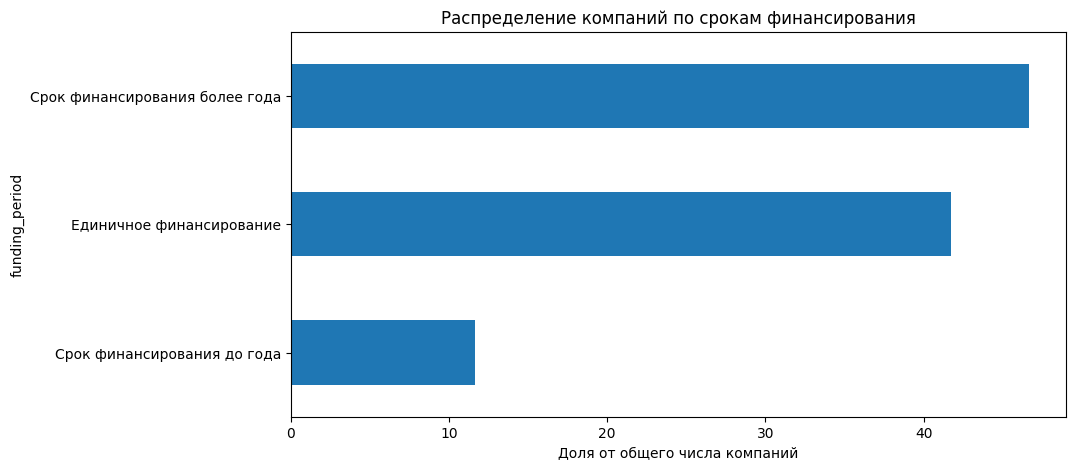

In [24]:
# Соотношение компаний по их кол-ву
group_count = clean_cb_investments['funding_period'].value_counts().sort_values()
group_ratio = group_count / len(clean_cb_investments) * 100
group_ratio.plot(kind='barh', title='Распределение компаний по срокам финансирования', xlabel='Доля от общего числа компаний', figsize=(10, 5))
plt.show()

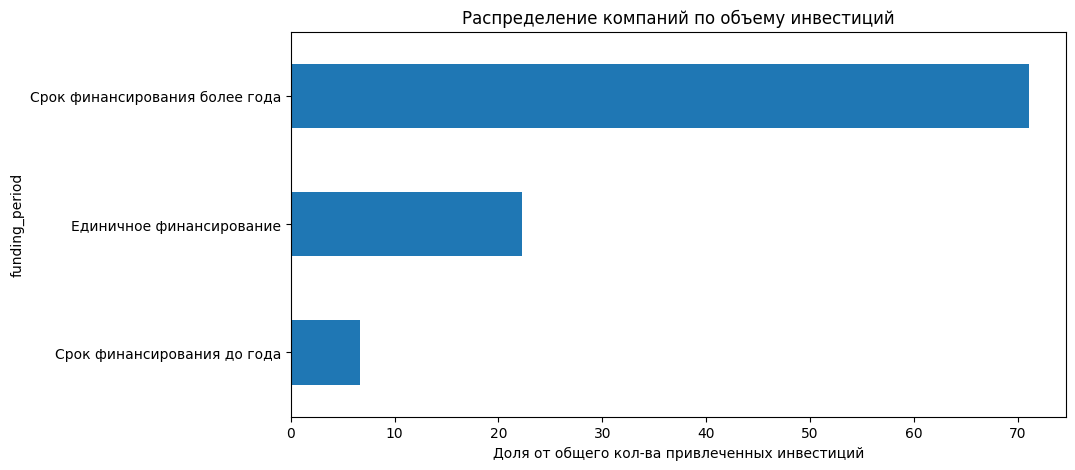

In [25]:
# Соотношение компаний по объему инвестиций
funding_by_group = clean_cb_investments.groupby('funding_period')['funding_total_usd'].sum().sort_values()
funding_ratio = funding_by_group / funding_by_group.sum() * 100
funding_ratio.plot(kind='barh', title='Распределение компаний по объему инвестиций', xlabel='Доля от общего кол-ва привлеченных инвестиций', figsize=(10, 5))
plt.show()

Наиболее часто в данных встречаются компании со **сроком финансирования более года** и с **единичным финансированием**. <br> Наибольшее количество инвестиций с внушительным преимуществом наблюдается в компаниях со **сроком финансирования более года**.

### Выделение средних и нишевых сегментов рынка

Разделим сегменты на три категории:
* Массовые сегменты — более 120 компаний;
* Средние сегменты — от 35 до 120 компаний;
* Нишевые сегменты — до 35 компаний.


In [26]:
# Определяем сегменты рынка
market_count = clean_cb_investments['market'].value_counts()

def categorize_segment(count):
    if count > 120:
        return 'Массовый сегмент'
    elif count >= 35 and count <= 120:
        return 'Средний сегмент'
    elif count < 35:
        return 'Нишевый сегмент'

segment_categories = market_count.apply(categorize_segment)
segment_count = segment_categories.value_counts()
segment_count

count
Нишевый сегмент     425
Средний сегмент      34
Массовый сегмент     21
Name: count, dtype: int64

C:\Users\Mi\AppData\Local\Temp\ipykernel_12016\3459415716.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  clean_cb_investments['segment_type'] = clean_cb_investments['market'].map(segment_categories) # создали столбец в датафрейме с сегментами


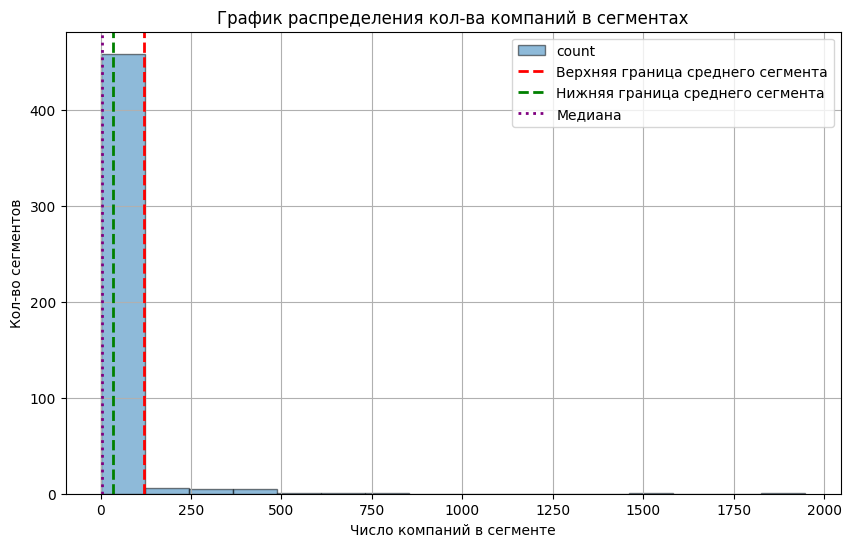

In [27]:
clean_cb_investments['segment_type'] = clean_cb_investments['market'].map(segment_categories) # создали столбец в датафрейме с сегментами
category_count = clean_cb_investments['segment_type'].value_counts()

market_count.plot(kind='hist', bins=16, title='График распределения кол-ва компаний в сегментах', ylabel='Кол-во сегментов', xlabel='Число компаний в сегменте', legend=True, grid=True, edgecolor='black', alpha=0.5, figsize=(10, 6))
plt.axvline(120, color='red', linestyle='--', linewidth=2, label='Верхняя граница среднего сегмента')
plt.axvline(35, color='green', linestyle='--', linewidth=2, label='Нижняя граница среднего сегмента')
plt.axvline(3, color='purple', linestyle=':', linewidth=2, label='Медиана')

plt.legend()
plt.show()

Большинство компаний работают в **массовом сегменте**.

In [28]:
# В столбце market оставляем только массовые сегменты, для остальных создаем заглушки
def get_replacement(segment):
    category = segment_categories.get(segment)
    if category == 'Массовый сегмент':
        return segment
    elif category == 'Средний сегмент':
        return 'mid'
    elif category == 'Нишевый сегмент':
        return 'niche'

clean_cb_investments['market'] = clean_cb_investments['market'].apply(get_replacement)

C:\Users\Mi\AppData\Local\Temp\ipykernel_12016\3673443769.py:11: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  clean_cb_investments['market'] = clean_cb_investments['market'].apply(get_replacement)


## Работа с выбросами и анализ

### Анализируем и помечаем выбросы в каждом из сегментов

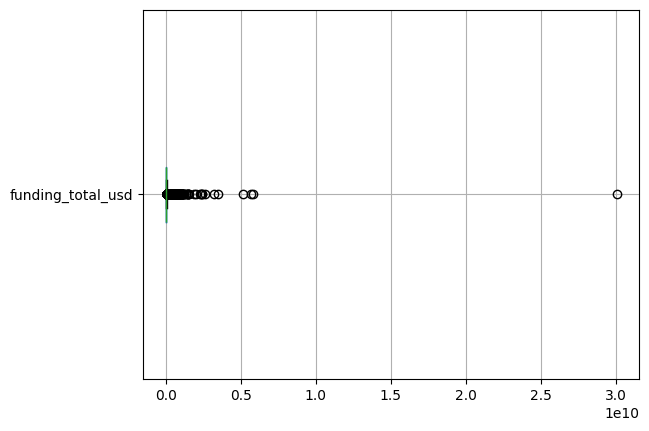

In [29]:
# Построим ящик с усами
boxplot = clean_cb_investments.boxplot(column='funding_total_usd', vert=False)

Типичными будут значения до 500 000 000 млн. Выбиваются значения больше этой суммы.

In [30]:
# Определяем компании с аномальным объемом общего финансирования
clean_cb_investments['is_outlier'] = False
segment_types = clean_cb_investments['segment_type'].unique()

def outliers_iqr(clean_cb_investments):
    q1 = clean_cb_investments['funding_total_usd'].quantile(0.25)
    q3 = clean_cb_investments['funding_total_usd'].quantile(0.75)
    iqr = q3-q1
    lower_bound = q1 - 1.5 * iqr
    upper_bound = q3 + 1.5 * iqr
    return (clean_cb_investments['funding_total_usd'] < lower_bound) | (clean_cb_investments['funding_total_usd'] > upper_bound)

for segment in segment_types:
    segment_mask = clean_cb_investments['segment_type'] == segment
    segment_data = clean_cb_investments[segment_mask]
    outlier_mask_segment = outliers_iqr(segment_data)
    clean_cb_investments.loc[segment_mask, 'is_outlier'] = outlier_mask_segment.values
    
    print(f"\n--- Сегмент: {segment} ---")
    print(f"Всего компаний в сегменте: {len(segment_data)}")
    print(f"Выбросов: {outlier_mask_segment.sum()}")
    print(f"Медиана финансирования в сегменте: {segment_data['funding_total_usd'].median():.2f}")
    print(f"Q1: {segment_data['funding_total_usd'].quantile(0.25):.2f}")
    print(f"Q3: {segment_data['funding_total_usd'].quantile(0.75):.2f}")



--- Сегмент: Массовый сегмент ---
Всего компаний в сегменте: 10325
Выбросов: 1310
Медиана финансирования в сегменте: 4512488.00
Q1: 974709.00
Q3: 18600000.00

--- Сегмент: Нишевый сегмент ---
Всего компаний в сегменте: 2238
Выбросов: 317
Медиана финансирования в сегменте: 2537753.00
Q1: 417540.25
Q3: 16146251.00

--- Сегмент: Средний сегмент ---
Всего компаний в сегменте: 2053
Выбросов: 301
Медиана финансирования в сегменте: 2558943.00
Q1: 432000.00
Q3: 14037121.00


C:\Users\Mi\AppData\Local\Temp\ipykernel_12016\3519633194.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  clean_cb_investments['is_outlier'] = False


In [31]:
# Топ сегментов с аномальным финансированием
outlier_by_market = clean_cb_investments.groupby('market')['is_outlier'].mean().sort_values(ascending=False) * 100
outlier_by_market = outlier_by_market[outlier_by_market > 0] 

outlier_by_market.head()

market
Semiconductors       27.111111
Clean Technology     26.077098
Health Care          24.048443
Web Hosting          18.823529
Biotechnology        17.659138
Name: is_outlier, dtype: float64

Наибольшее кол-во аномалий наблюдается в **массовом сегменте**. Самая большая доля компаний, получивших аномальное финансирование, наблюдается в сегменте Semiconductors.

### Определяем границы рассматриваемого периода, отбрасываем аномалии

In [32]:
# Проверяем даты
print(f"Диапазон дат founded_at:")
print(f"  Min: {clean_cb_investments['founded_at'].min()}")
print(f"  Max: {clean_cb_investments['founded_at'].max()}")

print(f"Диапазон дат first_funding_at:")
print(f"  Min: {clean_cb_investments['first_funding_at'].min()}")
print(f"  Max: {clean_cb_investments['first_funding_at'].max()}")

print(f"Диапазон дат last_funding_at:")
print(f"  Min: {clean_cb_investments['last_funding_at'].min()}")
print(f"  Max: {clean_cb_investments['last_funding_at'].max()}")

Диапазон дат founded_at:
  Min: 1785-01-01 00:00:00
  Max: 2014-10-30 00:00:00
Диапазон дат first_funding_at:
  Min: 1960-11-01 00:00:00
  Max: 2014-12-02 00:00:00
Диапазон дат last_funding_at:
  Min: 1960-11-01 00:00:00
  Max: 2014-12-02 00:00:00


Верхняя граница - 2 декабря 2014. Соответственно, данные за 2014 год можно считать неполными, т.к. отсутствуют данные практически за целый месяц (с 3 по 31 декабря).

In [33]:
# Удаляем аномальные компании
clean_cb_investments = clean_cb_investments[clean_cb_investments['is_outlier'] == False]

In [34]:
# Фильтруем годы по условия >50 раундов
clean_cb_investments['funding_year'] = pd.to_datetime(clean_cb_investments['mid_funding_at']).dt.year
yearly_rounds = clean_cb_investments.groupby('funding_year')['funding_rounds'].sum().reset_index()
years_to_analyze = yearly_rounds[yearly_rounds['funding_rounds'] >= 50]['funding_year'].tolist()
filtered_df = clean_cb_investments[clean_cb_investments['funding_year'].isin(years_to_analyze)]

### Анализ типов финансирования по объёму и популярности

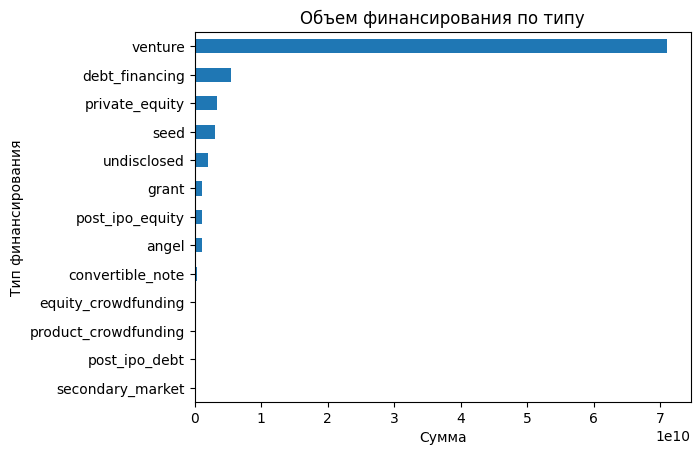

In [35]:
# Строим график объема финансирования по его типу
funding_types = [
    'seed', 'venture', 'equity_crowdfunding', 'undisclosed', 
    'convertible_note', 'debt_financing', 'angel', 'grant', 
    'private_equity', 'post_ipo_equity', 'post_ipo_debt', 
    'secondary_market', 'product_crowdfunding'
]

funding_totals = filtered_df[funding_types].sum().sort_values(ascending=True)

funding_totals.plot(kind='barh', title='Объем финансирования по типу', ylabel='Тип финансирования', xlabel='Сумма')
plt.show()

Наибольшее кол-во денег привнесли венчурные инвестиции.

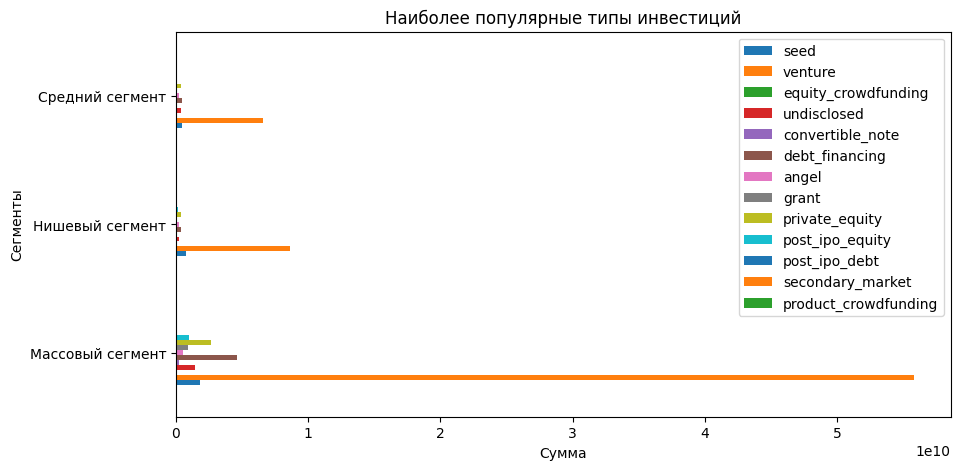

In [36]:
# Строим график популярных типов инвестицй
funding_types = [
    'seed', 'venture', 'equity_crowdfunding', 'undisclosed', 
    'convertible_note', 'debt_financing', 'angel', 'grant', 
    'private_equity', 'post_ipo_equity', 'post_ipo_debt', 
    'secondary_market', 'product_crowdfunding'
]

popularity = filtered_df.groupby('segment_type')[funding_types].sum()

popularity.plot(kind='barh', title='Наиболее популярные типы инвестиций', ylabel='Сегменты', xlabel='Сумма', figsize=(10, 5))
plt.show()

<Axes: title={'center': 'Суммарные объёмы возвратов по типам финансирования'}, xlabel='Сумма возвратов (USD)', ylabel='Тип финансирования'>

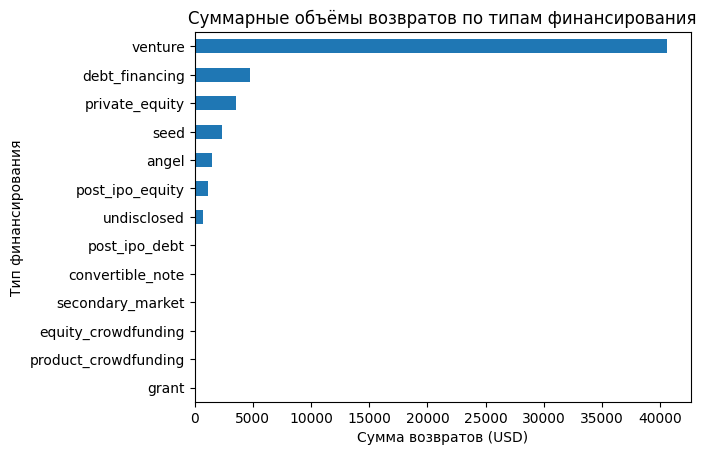

In [37]:
# Строим график объемов возвратов по типам финансирования
return_types = [
    'seed', 'venture', 'equity_crowdfunding', 'undisclosed',
    'convertible_note', 'debt_financing', 'angel', 'grant',
    'private_equity', 'post_ipo_equity', 'post_ipo_debt',
    'secondary_market', 'product_crowdfunding'
]

total_returns = cb_returns[return_types].sum().sort_values(ascending=True)

total_returns.plot(
    kind='barh',
    title='Суммарные объёмы возвратов по типам финансирования',
    xlabel='Сумма возвратов (USD)',
    ylabel='Тип финансирования')

Основным источником финансирования с большим отрывом являются **венчурные инвестиции**.

## Анализ динамики

### Динамика предоставления финансирования по годам

In [38]:
# Рассчитываем средний объем одного раунда финансирования
filtered_df['mean_round_size'] = filtered_df['funding_total_usd'] / filtered_df['funding_rounds']

C:\Users\Mi\AppData\Local\Temp\ipykernel_12016\1960251467.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  filtered_df['mean_round_size'] = filtered_df['funding_total_usd'] / filtered_df['funding_rounds']


<Axes: title={'center': 'Динамика финансирования одного раунда по годам'}, xlabel='Год финансирования', ylabel='Размер финансирования одного раунда'>

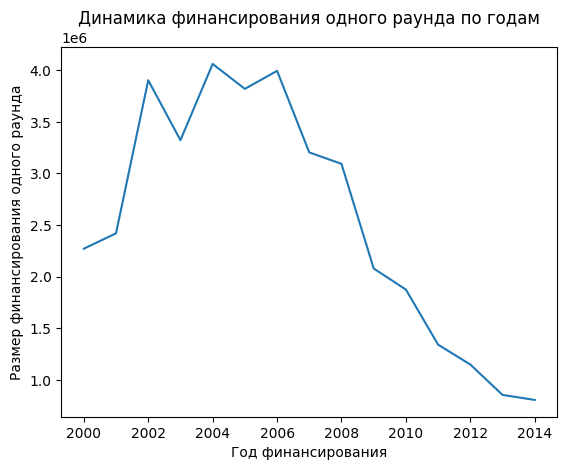

In [39]:
# Рассмотрим динамику финансирования одного раунда по годам
yearly_median = filtered_df.groupby('funding_year')['mean_round_size'].median()

yearly_median.plot.line(xlabel='Год финансирования', ylabel='Размер финансирования одного раунда', title='Динамика финансирования одного раунда по годам')

Максимальный размер средств, собранных в рамках одного раунда, зафиксирован в 2004 году.

<Axes: title={'center': 'Динамика общего количества раундов за каждый год'}, xlabel='Год финансирования', ylabel='Кол-во раундов'>

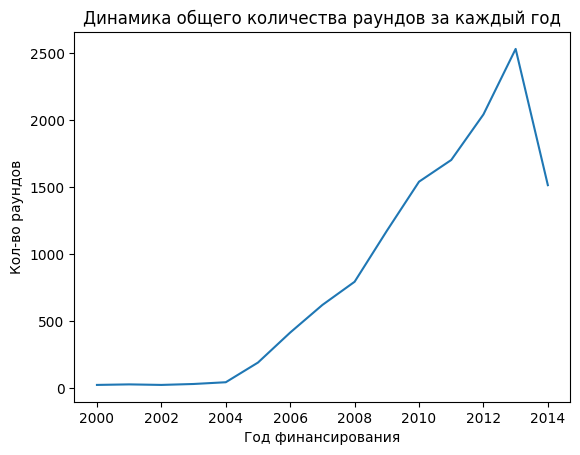

In [40]:
# Рассмотрим динамику общего кол-ва раундов за каждый год
yearly_rounds = filtered_df.groupby('funding_year')['funding_rounds'].count()

yearly_rounds.plot.line(xlabel='Год финансирования', ylabel='Кол-во раундов', title='Динамика общего количества раундов за каждый год')

### Динамика размера общего финансирования по массовым сегментам рынка для растущих в 2014 году сегментов

In [41]:
# Рассмотрим суммарный размер общего финансирования по годам и сегментам рынка
pivot_table = pd.pivot_table(
    filtered_df,
    values='funding_total_usd',
    index='market',
    columns='funding_year',
    aggfunc='mean',
    fill_value=0
)
print(pivot_table)

funding_year                   2000        2001          2002        2003  \
market                                                                      
 Advertising           6.250000e+06   8778321.0  0.000000e+00         0.0   
 Analytics             1.362280e+07         0.0  0.000000e+00         0.0   
 Biotechnology         0.000000e+00         0.0  0.000000e+00  22811685.0   
 Clean Technology      0.000000e+00         0.0  3.439044e+07   2175000.0   
 Curated Web           0.000000e+00    305000.0  1.647500e+07  15071350.0   
 E-Commerce            1.179052e+06         0.0  0.000000e+00         0.0   
 Education             0.000000e+00         0.0  4.695420e+05         0.0   
 Enterprise Software   1.353815e+06   2180175.0  9.280498e+06   7669661.0   
 Finance               0.000000e+00         0.0  0.000000e+00  25320000.0   
 Games                 1.035939e+07         0.0  5.025000e+06  10748830.0   
 Hardware + Software   0.000000e+00         0.0  0.000000e+00  11600000.0   

In [42]:
# Отбираем сегменты, которые показали рост в 2014 г.
growth_mask = pivot_table[2014] > pivot_table[2013]
growing_segments = pivot_table[growth_mask]
growing_segments[[2013, 2014]]

funding_year,2013,2014
market,,
Curated Web,4.415060e+06,9.021761e+06
E-Commerce,3.847812e+06,4.552118e+06
Semiconductors,1.143158e+07,1.420702e+07
unknown,2.235030e+06,2.809495e+06


<Axes: title={'center': 'Динамика суммарного финансирования по отобранным сегментам'}, xlabel='Год', ylabel='Суммарное финансирование'>

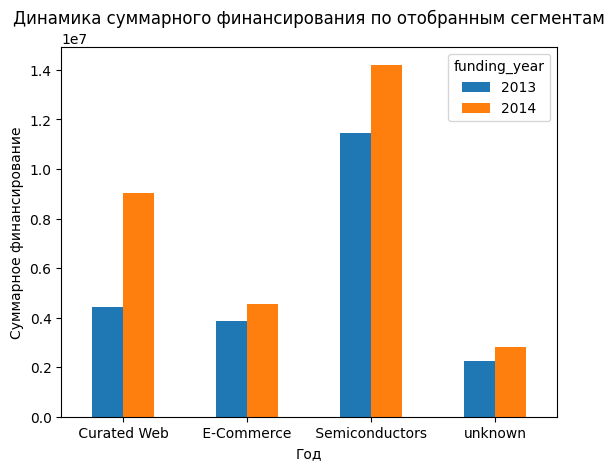

In [43]:
# Строим график
mass_markets_list = filtered_df[filtered_df['segment_type'] == 'Массовый сегмент']['market'].unique()
years_to_show = [2013, 2014]
mass_growing = growing_segments[growing_segments.index.isin(mass_markets_list)]
mass_growing_filtered = mass_growing[years_to_show]

mass_growing_filtered.plot(kind='bar', xlabel='Год', ylabel='Суммарное финансирование', title='Динамика суммарного финансирования по отобранным сегментам', rot=0)

Наиболее быстрый рост показывают Curated Web и Semiconductors.

### Годовая динамика доли возвращённых средств по типам финансирования

In [44]:
# Рассчитываем возвраты средств для каждого года и вида финансирования
funding_types = ['seed', 'venture', 'equity_crowdfunding', 'undisclosed', 
                 'convertible_note', 'debt_financing', 'angel', 'grant', 
                 'private_equity', 'post_ipo_equity', 'post_ipo_debt', 
                 'secondary_market', 'product_crowdfunding']

results = []

for year in filtered_df['funding_year'].unique():
    # Фильтруем данные по году
    funding_year_data = filtered_df[filtered_df['funding_year'] == year]
    returns_year_data = cb_returns[cb_returns['year'] == year]

    if len(returns_year_data) == 0:
        continue

    for ftype in funding_types:
        total_funding = funding_year_data[ftype].sum()
        total_returns = returns_year_data[ftype].sum()

        if total_funding > 0:
            norm_value = total_returns / (total_funding + 1e-60)
        else:
            norm_value = pd.NA

        results.append({
            'year': year,
            'funding_type': ftype,
            'total_funding': total_funding,
            'total_returns': total_returns,
            'normalized_return': norm_value
        })

result_df = pd.DataFrame(results)

pivot_result = result_df.pivot_table(
    values='normalized_return',
    index='year',
    columns='funding_type',
    aggfunc='first'
)

print(pivot_result)

funding_type     angel convertible_note debt_financing equity_crowdfunding  \
year                                                                         
2000          0.000007              NaN            NaN                 NaN   
2001          0.000003              NaN       0.000001                 NaN   
2002               NaN              NaN            0.0                 NaN   
2003               0.0              NaN            0.0                 NaN   
2004          0.000002              NaN       0.000001                 NaN   
2005          0.000002              NaN       0.000001                 NaN   
2006          0.000002              0.0       0.000001                 0.0   
2007          0.000003              0.0       0.000001                 NaN   
2008          0.000001              0.0       0.000001                 NaN   
2009          0.000001              0.0       0.000001                 0.0   
2010          0.000001              0.0       0.000001          

<Axes: title={'center': 'Нормированный возврат средств по типам финансирования'}, xlabel='Год', ylabel='Нормированный возврат'>

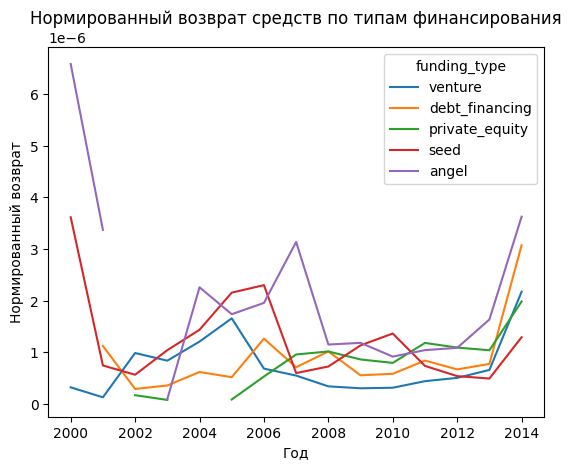

In [45]:
# Строим график
selected_types = ['venture', 'debt_financing', 'private_equity', 'seed', 'angel']
plot_data = pivot_result[selected_types]

plot_data.plot.line(xlabel='Год', ylabel='Нормированный возврат', title='Нормированный возврат средств по типам финансирования')

Наиболее устойчивый рост наблюдается в типах `angel` и `debt_financing`.

## Итоговый вывод и рекомендации

Рекомендовано рассмотреть в качестве отраслей для инвестиций Curated Web и Semiconductors. Наиболее уместными рассмотреть такие типы инвестиций, как долговое финансирование или финансирование от бизнес-ангелов.  

Для корректного проведения анализа были обработаны предоставленные датасеты: удалены или заменены пропуски и дубликаты в данных, данные приведены к единому и адекватному формату, удалены выбросы в данных. Проведен анализ типов финансирования по объёму и популярности, рассмотрена динамика финансирования раундов по размеру и количеству, динамика возврата средств.